<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
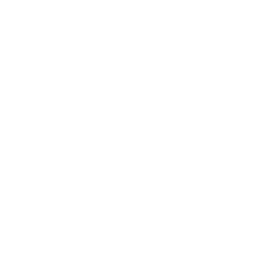
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kodowanie zdarzeń niepożądanych w badaniu klinicznym</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacja / Nadzór nad bezpieczeństwem leków &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Streszczenie

Zbiory danych o zdarzeniach niepożądanych trafiają do analizy z dosłownymi
preferowanymi terminami MedDRA, natomiast regulacyjne tabele bezpieczeństwa
są organizowane według klasy układowo-narządowej (SOC). Ten przykład buduje
format wartości PROC FORMAT, który mapuje każdy termin preferowany na jego
SOC, a następnie wykorzystuje ten sam format do napędzania każdej kolejnej
tabulacji: krzyżową tabelę PROC FREQ SOC według ramienia leczenia, podział
SOC według nasilenia oraz podsumowanie poważnych zdarzeń niepożądanych.
Ponieważ mapowanie istnieje tylko w jednym miejscu — w formacie — przejście
badania na nową wersję MedDRA to edycja jednego formatu, a nie przepisanie
każdego raportu. ODS OUTPUT przechwytuje częstości SOC jako zbiór danych do
dalszego przeglądu sygnałów bezpieczeństwa.


## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------:|
| WORK.AE_RAW | Syntetyczne rekordy zdarzeń niepożądanych z preferowanymi terminami MedDRA | 100 |
| WORK.RANDOMIZATION | Przydział uczestników do ramion leczenia | 100 |

Środowisko działa w trybie bez licencji, więc każda wygenerowana tabela jest
ograniczona do 100 obserwacji. Scenariusz jest dopasowany do tego limitu:
100 zdarzeń niepożądanych wylosowanych z 12-terminowego panelu MedDRA
typowego dla badania onkologicznego.


---

In [1]:
/* --------------------------------------------------------
   Wygeneruj syntetyczny zbiór danych o zdarzeniach niepożądanych
   Preferowane terminy MedDRA zmapowane na kategorie SOC
   -------------------------------------------------------- */
DANE work.ae_raw;
    DŁUGOŚĆ aedecod $40 aesev $12;
    CALL streaminit(42);
    TABLICA pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    POWTÓRZ i = 1 TO 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', ZAPISZ(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        /* Preferowany termin przypisywany przez if/else zamiast
           tablicy _temporary_ -- unika obcinania wartości
           zawierających znaki diakrytyczne */
        JEŚLI pt_idx = 1 WTEDY aedecod = 'Nudności';
        PRZECIWNIE JEŚLI pt_idx = 2 WTEDY aedecod = 'Ból głowy';
        PRZECIWNIE JEŚLI pt_idx = 3 WTEDY aedecod = 'Wymioty';
        PRZECIWNIE JEŚLI pt_idx = 4 WTEDY aedecod = 'Biegunka';
        PRZECIWNIE JEŚLI pt_idx = 5 WTEDY aedecod = 'Kaszel';
        PRZECIWNIE JEŚLI pt_idx = 6 WTEDY aedecod = 'Zmęczenie';
        PRZECIWNIE JEŚLI pt_idx = 7 WTEDY aedecod = 'Bóle stawów';
        PRZECIWNIE JEŚLI pt_idx = 8 WTEDY aedecod = 'Gorączka';
        PRZECIWNIE JEŚLI pt_idx = 9 WTEDY aedecod = 'Ból brzucha';
        PRZECIWNIE JEŚLI pt_idx = 10 WTEDY aedecod = 'Neutropenia';
        PRZECIWNIE JEŚLI pt_idx = 11 WTEDY aedecod = 'Gorączka neutropeniczna';
        PRZECIWNIE aedecod = 'Reakcja związana z infuzją';
        sev_idx = int(rand('uniform') * 3) + 1;
        JEŚLI pt_idx IN (10, 11) WTEDY sev_idx = MAX(sev_idx, 2);
        JEŚLI sev_idx = 1 WTEDY aesev = 'ŁAGODNE';
        PRZECIWNIE JEŚLI sev_idx = 2 WTEDY aesev = 'UMIARKOWANE';
        PRZECIWNIE aesev = 'CIĘŻKIE';
        aeser = ifc(aesev = 'CIĘŻKIE' AND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        JEŚLI aestdy > 365 WTEDY aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', ZAPISZ(int(rand('uniform') * 25) + 1, z3.));
        WYJŚCIE;
    KONIEC;
    USUŃ i pt_idx sev_idx;
WYKONAJ;



NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.76 seconds
  cpu   1.76 seconds


In [2]:
/* --------------------------------------------------------
   Wygeneruj tabelę randomizacji uczestników
   -------------------------------------------------------- */
DANE work.randomization;
    CALL streaminit(43);
    TABLICA arms[3] $20 _temporary_ ('BADANY' 'AKTYWNY_KOMPARATOR' 'PLACEBO');
    POWTÓRZ subject_id = 1 TO 800;
        usubjid = cat('ONC-2025-', ZAPISZ(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arms[arm_idx];
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        WYJŚCIE;
    KONIEC;
    USUŃ arm_idx;
    format randomization_date date9.;
WYKONAJ;



NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---

                               Częstość surowych terminów preferowanych (niezmapowanych)                                

                                                   The FREQ Procedure

Termin preferowany (MedDRA)     Frequency    Percent
-----------------------------------------------------
Biegunka                               12     12.00
Ból głowy                              12     12.00
Gorączka                               11     11.00
Zmęczenie                              11     11.00
Bóle stawów                            10     10.00
Nudności                               10     10.00
Reakcja związana z infuzją              8      8.00
Kaszel                                  7      7.00
Ból brzucha                             5      5.00
Gorączka neutropeniczna                 5      5.00
Neutropenia                             5      5.00
Wymioty                                 4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


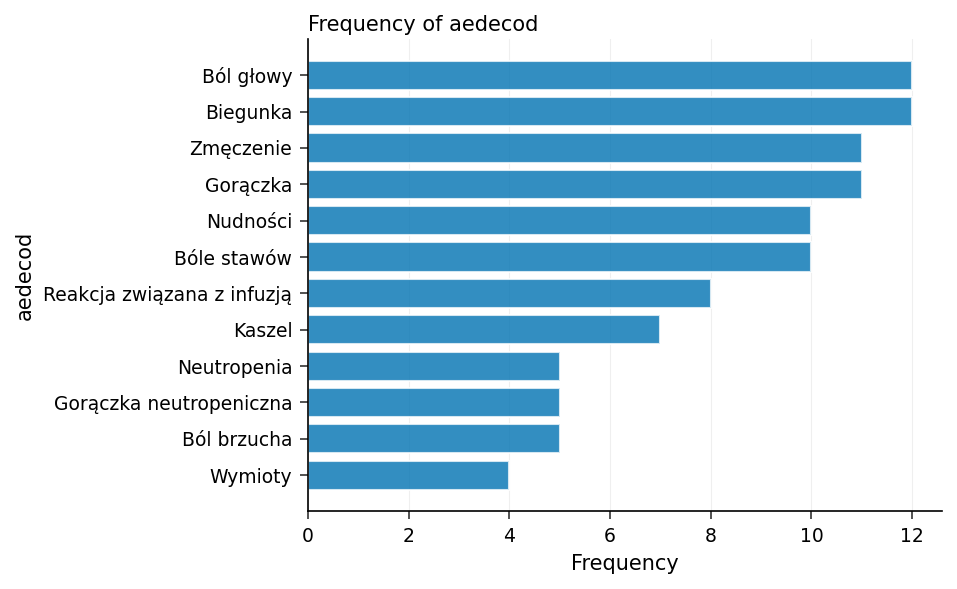

In [3]:
/* --------------------------------------------------------
   Częstość surowych terminów preferowanych przed mapowaniem SOC
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.ae_raw ORDER=CZĘSTOŚCI;
    TABLES aedecod / nocum;
    ETYKIETA aedecod="Termin preferowany (MedDRA)";
    TYTUŁ 'Częstość surowych terminów preferowanych (niezmapowanych)';
WYKONAJ;


---

                               Częstość surowych terminów preferowanych (niezmapowanych)                                




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


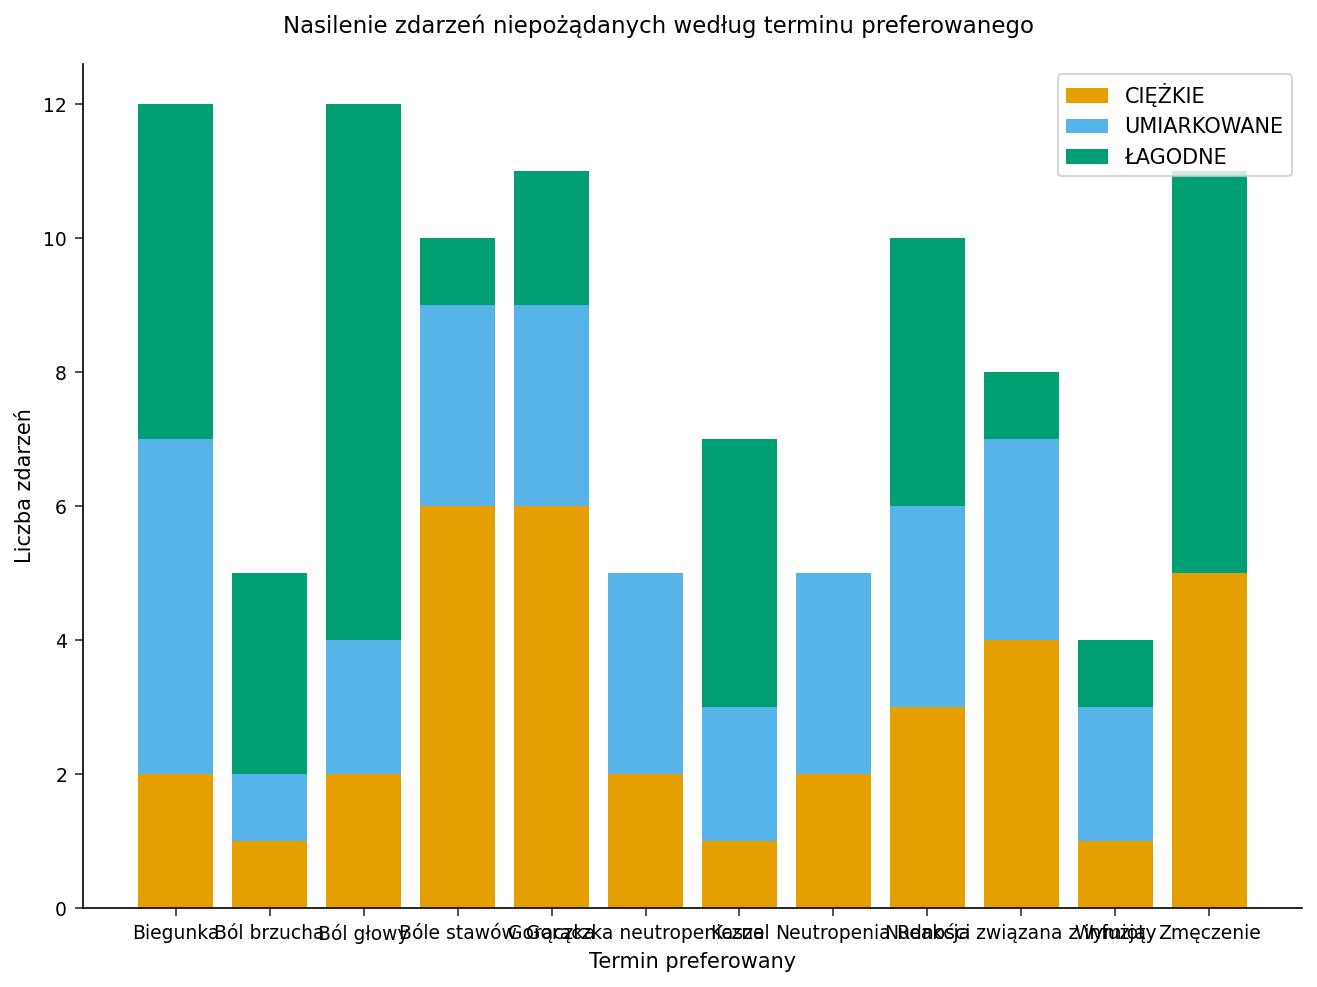

In [4]:
/* --------------------------------------------------------
   Rozkład nasilenia AE według terminu preferowanego
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS ETYKIETA='Termin preferowany' fitpolicy=ROTATE;
    YAXIS ETYKIETA='Liczba zdarzeń';
    TYTUŁ 'Nasilenie zdarzeń niepożądanych według terminu preferowanego';
WYKONAJ;


---

In [5]:
/* --------------------------------------------------------
   Zdefiniuj format wartości preferowany termin MedDRA -> klasa
   układowo-narządowa (SOC). Format jest kluczowany tekstem terminu
   preferowanego, więc jedno wywołanie PUT() koduje każdy rekord AE
   do jego SOC.
   -------------------------------------------------------- */
PROCEDURA format;
    VALUE $pt_to_soc
        'Nudności'                    = 'Zaburzenia żołądkowo-jelitowe'
        'Wymioty'                     = 'Zaburzenia żołądkowo-jelitowe'
        'Biegunka'                    = 'Zaburzenia żołądkowo-jelitowe'
        'Ból brzucha'                 = 'Zaburzenia żołądkowo-jelitowe'
        'Ból głowy'                   = 'Zaburzenia układu nerwowego'
        'Zmęczenie'                   = 'Zaburzenia ogólne'
        'Gorączka'                    = 'Zaburzenia ogólne'
        'Kaszel'                      = 'Zaburzenia układu oddechowego'
        'Bóle stawów'                 = 'Zaburzenia mięśniowo-szkieletowe'
        'Neutropenia'                 = 'Zaburzenia krwi i układu chłonnego'
        'Gorączka neutropeniczna'     = 'Zaburzenia krwi i układu chłonnego'
        'Reakcja związana z infuzją'  = 'Zaburzenia układu odpornościowego'
        OTHER                         = 'Niezakodowane'
    ;
    VALUE $sev_rank
        'ŁAGODNE'     = '1-Łagodne'
        'UMIARKOWANE' = '2-Umiarkowane'
        'CIĘŻKIE'     = '3-Ciężkie'
        OTHER         = '9-Nieznane'
    ;
    VALUE $serious_fmt
        'Y' = 'Poważne'
        'N' = 'Niepoważne'
    ;
WYKONAJ;



NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Połącz rekordy AE z ramieniem leczenia, a następnie zastosuj
   format SOC. PUT(aedecod, $pt_to_soc.) to jedyny potrzebny krok
   mapowania; nasilenie i poważność są kodowane w ten sam sposób.
   -------------------------------------------------------- */
PROCEDURA SORTUJ DANE=work.ae_raw; WEDŁUG usubjid; WYKONAJ;
PROCEDURA SORTUJ DANE=work.randomization; WEDŁUG usubjid; WYKONAJ;

DANE work.ae_coded;
    DŁUGOŚĆ soc_class $45 severity_rank $16 serious_flag $16;
    POŁĄCZ work.ae_raw (IN=a)
          work.randomization (IN=b ZACHOWAJ=usubjid treatment_arm);
    WEDŁUG usubjid;
    JEŚLI a;
    soc_class     = ZAPISZ(aedecod, $pt_to_soc.);
    severity_rank = ZAPISZ(aesev,   $sev_rank.);
    serious_flag  = ZAPISZ(aeser,   $serious_fmt.);
WYKONAJ;



NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


                            Częstość AE według klasy układowo-narządowej i ramienia leczenia                            

                                                   The FREQ Procedure

Table of Klasa układowo-narządowa (SOC) by Ramię leczenia

Klasa układowo-narządowa (SOC)       |AKTYWNY_KOMPARATOR |            BADANY |           PLACEBO |              Total
-------------------------------------+-------------------+-------------------+-------------------+-------------------
Zaburzenia krwi i układu chłonnego   |                 0 |                 1 |                 1 |                  2
-------------------------------------+-------------------+-------------------+-------------------+-------------------
Zaburzenia ogólne                    |                 1 |                 1 |                 3 |                  5
-------------------------------------+-------------------+-------------------+-------------------+-------------------
Zaburzenia układu odpornościowego    |  


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


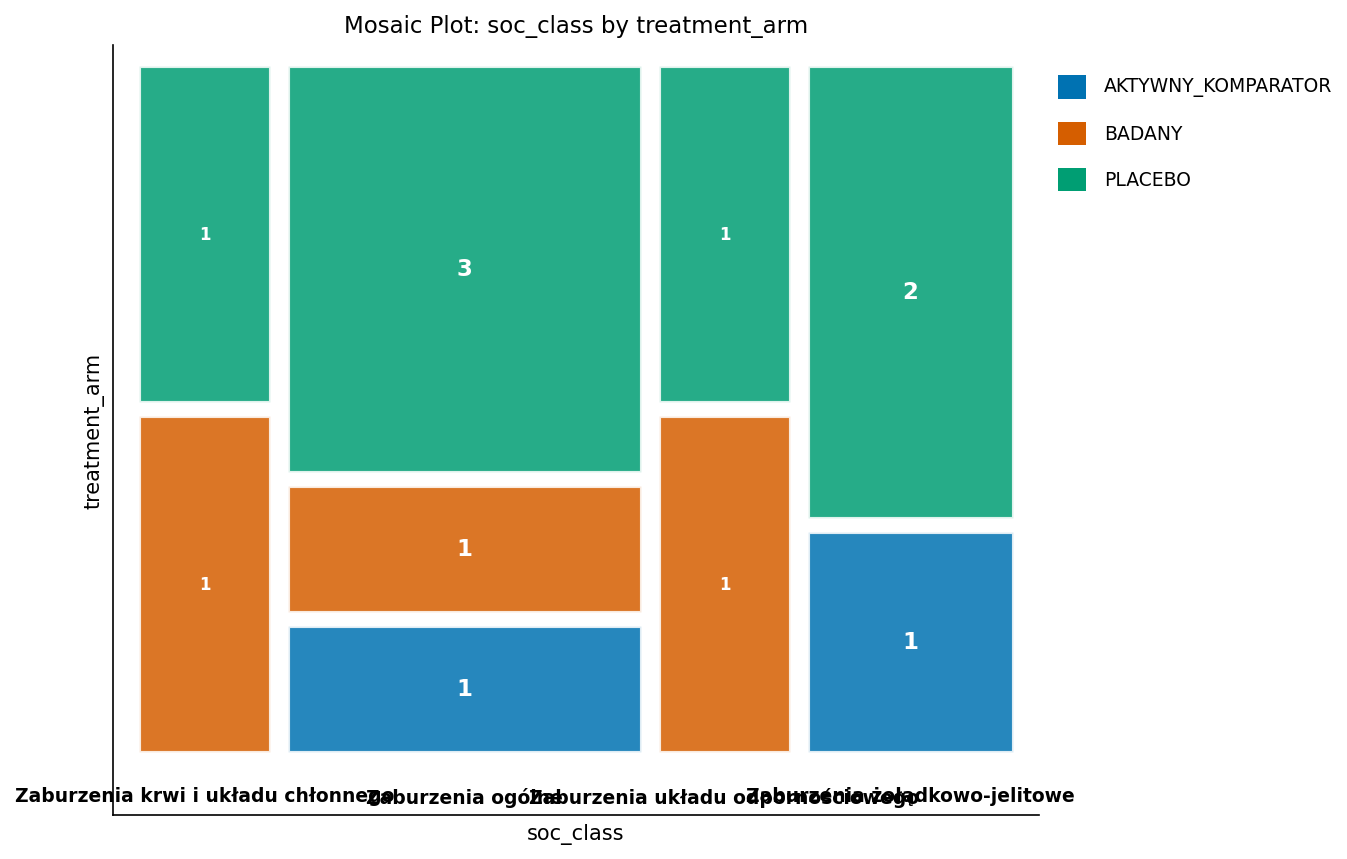

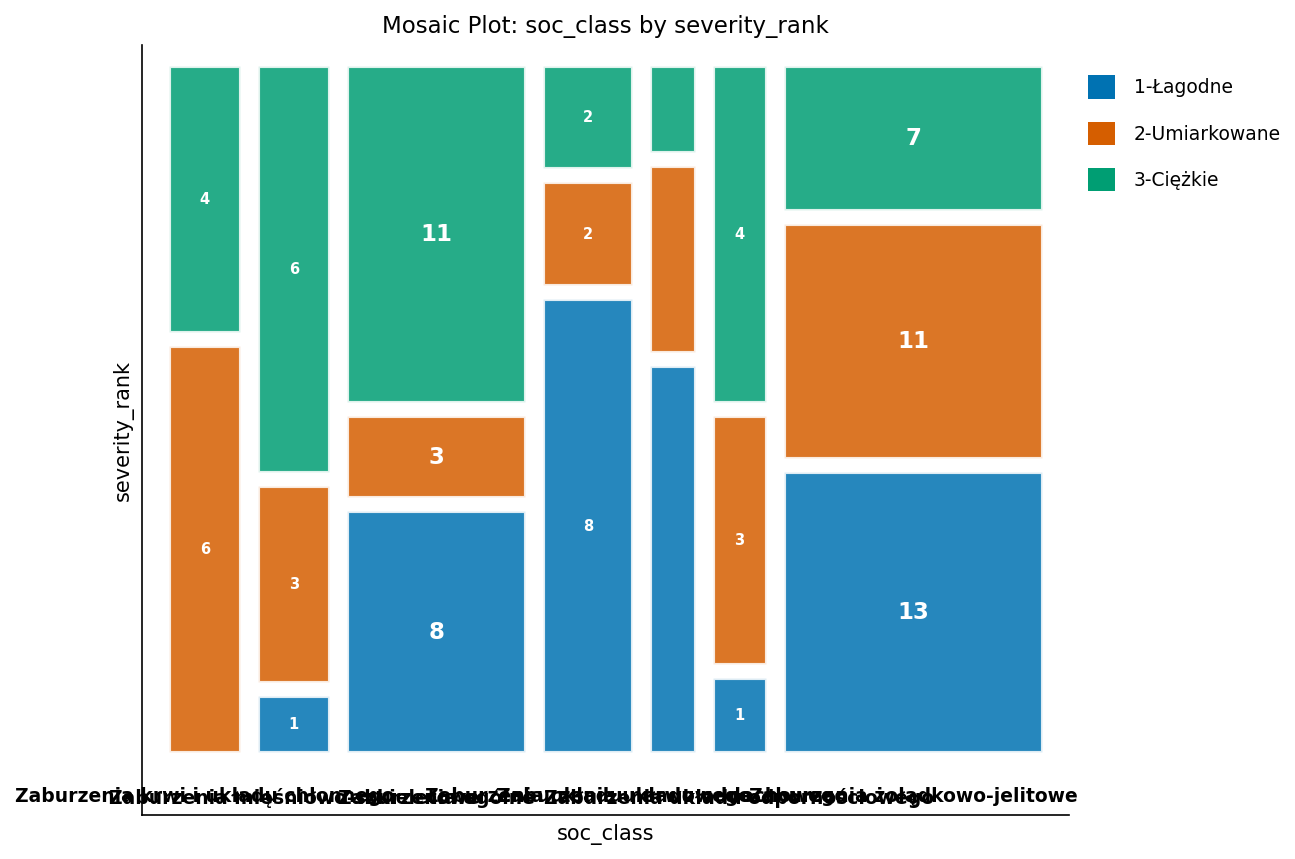

In [7]:
/* --------------------------------------------------------
   Częstość na poziomie SOC według ramienia leczenia
   ODS OUTPUT przechwytuje wyniki do wykrywania sygnałów
   -------------------------------------------------------- */
ODS WYJŚCIE onewayfreqs=work.soc_freq_table;

PROCEDURA CZĘSTOŚCI DANE=work.ae_coded ORDER=CZĘSTOŚCI;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    ETYKIETA soc_class="Klasa układowo-narządowa (SOC)" treatment_arm="Ramię leczenia"
          severity_rank="Ranga nasilenia";
    TYTUŁ 'Częstość AE według klasy układowo-narządowej i ramienia leczenia';
WYKONAJ;

ODS WYJŚCIE CLOSE;


                              Poważne zdarzenia niepożądane według SOC i ramienia leczenia                              

                                                   The FREQ Procedure

Table of Klasa układowo-narządowa (SOC) by Ramię leczenia

Klasa układowo-narządowa (SOC)      |AKTYWNY_KOMPARATOR |            BADANY |           PLACEBO |              Total
------------------------------------+-------------------+-------------------+-------------------+-------------------
Zaburzenia ogólne                   |                 1 |                 1 |                 1 |                  3
------------------------------------+-------------------+-------------------+-------------------+-------------------
Zaburzenia układu odpornościowego   |                 0 |                 0 |                 1 |                  1
------------------------------------+-------------------+-------------------+-------------------+-------------------
Total                               |         


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


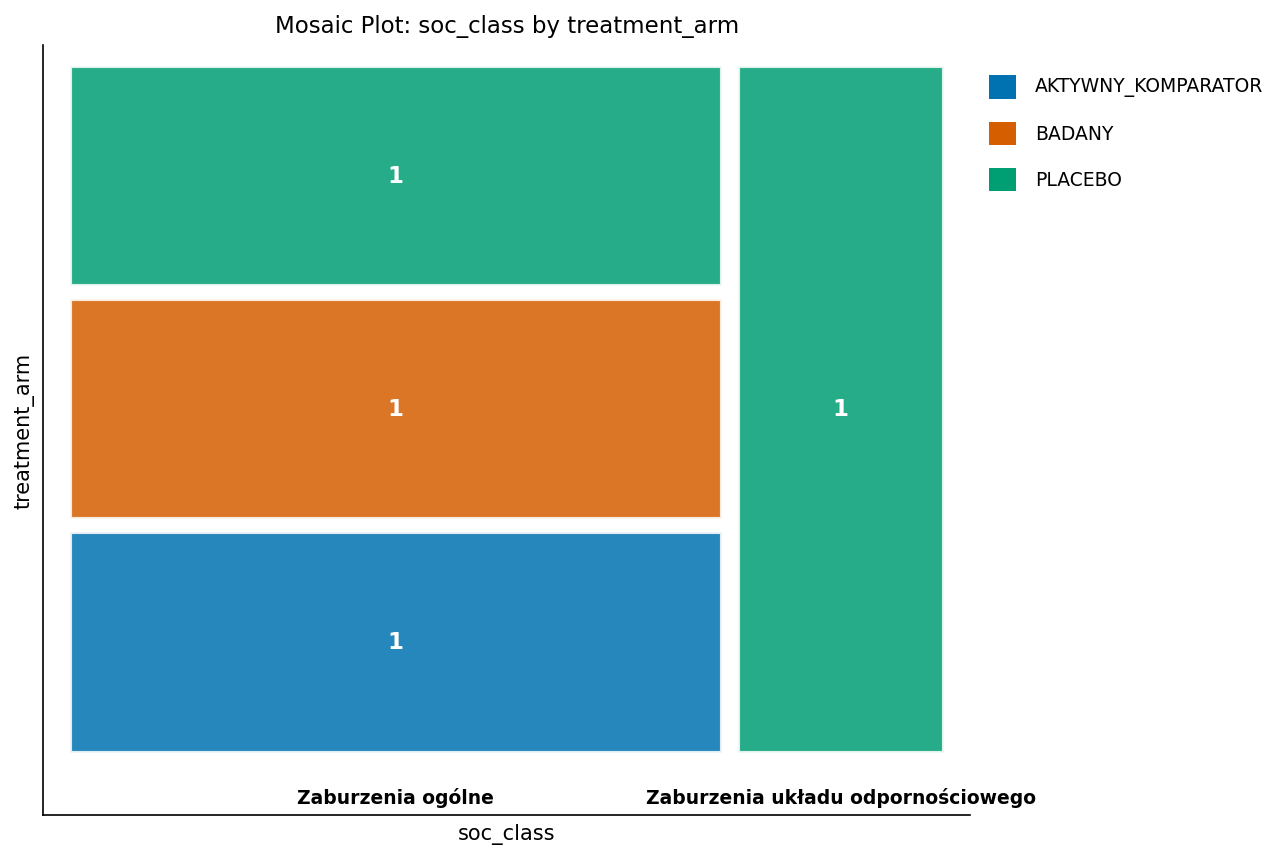

In [8]:
/* --------------------------------------------------------
   Podsumowanie poważnych AE według SOC dla narracji bezpieczeństwa
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.ae_coded;
    GDZIE aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    ETYKIETA soc_class="Klasa układowo-narządowa (SOC)" treatment_arm="Ramię leczenia";
    TYTUŁ 'Poważne zdarzenia niepożądane według SOC i ramienia leczenia';
WYKONAJ;


---

### Interpretacja

Jeden format wartości `$pt_to_soc` zakodował wszystkie 100 zdarzeń
niepożądanych z 12 dosłownych preferowanych terminów MedDRA do 7 klas
układowo-narządowych, i ten sam format napędzał każdą tabelę poniżej bez
przekodowywania danych.

Według SOC i nasilenia, **zaburzenia żołądkowo-jelitowe** to najczęstsza
klasa — 31 ze 100 zdarzeń (13 łagodnych, 11 umiarkowanych, 7 ciężkich),
a następnie **zaburzenia ogólne** z 22 zdarzeniami. Pozostałe klasy są
mniejsze: zaburzenia układu nerwowego (12), zaburzenia krwi i układu
chłonnego (10), zaburzenia mięśniowo-szkieletowe (10), zaburzenia układu
odpornościowego (8) oraz zaburzenia układu oddechowego (7). We wszystkich
zdarzeniach podział nasilenia to 35 łagodnych, 30 umiarkowanych i 35
ciężkich.

Tylko 4 zdarzenia oznaczono jako poważne (`aeser='Y'`): 3 w zaburzeniach
ogólnych (po jednym na ramię) i 1 w zaburzeniach układu odpornościowego
(placebo). Tabela krzyżowa SOC według ramienia leczenia jest zbudowana z
12 zdarzeń, których uczestnik pasował do rekordu randomizacji, więc liczby
na poziomie ramienia mają charakter poglądowy, a nie są dostosowane do
porównania między ramionami.

Kluczowym wnioskiem jest mechanizm FORMAT, a nie syntetyczne liczby:
ponieważ mapowanie terminu preferowanego na SOC istnieje wyłącznie w
PROC FORMAT, to samo wywołanie `PUT(aedecod, $pt_to_soc.)` przekodowuje
cały zbiór danych, a aktualizacja do nowej wersji słownika MedDRA oznacza
edycję jednego formatu zamiast każdego raportu. ODS OUTPUT przechwycił
częstości SOC jako `work.soc_freq_table` do dalszego przeglądu sygnałów
bezpieczeństwa.


---

In [9]:
/* --------------------------------------------------------
   Eksportuj zbiór danych AE zakodowany SOC do przeglądu sygnałów
   bezpieczeństwa. Pojedynczy format $pt_to_soc wypełnił soc_class,
   więc wyeksportowany plik jest gotowy do dalszej analizy na
   poziomie SOC.
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
WYKONAJ;



NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>